# Functionalised Pipeline

- In GPR23b, we made the ground truth an MCMC Fourier thingy.
- Now we will clean that code.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emcee
from scipy.optimize import minimize
from scipy.stats import norm
import celerite2
from celerite2 import terms
from prettytable import PrettyTable
import sys
from pathlib import Path
from IPython.display import display as ipy_display

sys.path.append(str(Path('../..').resolve()))
from helpers.df_ops import prepare_df, split_df, clean_df, downsample_min_gap
from helpers.priors import find_classify_signals, get_priors
from helpers.gpr import set_params, NLL
from helpers.MCMC import lnPost_gp
from helpers.eval import check_constant, fit_Fourier, truth_in_x

In [ ]:
def star_window_analysis(datapath, star_name, star_type='G', add_prefix=False,
             error_percent=2.5, sigma_upper_mult=5.0, q_bounds_in=(1, 5),
             n_target_windows=5, min_gap=3, n_walkers=32,
             total_sample_count=2500, subsample=500, SEED=1701,
             pred_forward_years=2, low_cad=30, high_cad=10,
             direct_bound_tol=0.1, sm2016_bound_tol=0.2, mean_bound_tol=1,
             require_mid=True, valid_metric='CRPS', verbose=False):
    '''
    Run the full GPR + Fourier ground truth pipeline on one star.
    Returns a nested dict; flatten with results_to_df().

    Return schema:
        {star, n_obs, span_years, skipped, skip_reason,
         splits: [{best_combo, valid_metric_value, rho_mid_years, Q_mid,
                   n_cycles_obs, is_const, aleatoric_frac_at_t0,
                   windows: [{lookahead_years, t0_year,
                              gpr_med, gpr_lb68, gpr_ub68, gpr_lb95, gpr_ub95,
                              truth_med, truth_lb, truth_ub,
                              error, abs_error, in_68, in_95,
                              gpr_width_68, truth_width}]}]}
    '''
    np.random.seed(SEED)

    #---Data Loading---
    try:
        raw_df = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)
        data_df = prepare_df(raw_df, add_prefix=add_prefix, relative=True)
    except Exception as e:
        return {'star': star_name, 'skipped': True, 'skip_reason': f'load error: {e}', 'splits': []}

    n_obs = len(data_df)
    if n_obs < 100:
        return {'star': star_name, 'n_obs': n_obs, 'skipped': True,
                'skip_reason': 'fewer than 100 observations', 'splits': []}

    span = data_df['year'].iloc[-1] - data_df['year'].iloc[0]
    if span < 1:
        return {'star': star_name, 'n_obs': n_obs, 'span_years': span,
                'skipped': True, 'skip_reason': 'span < 1 year', 'splits': []}

    data_df = downsample_min_gap(data_df, min_gap)

    #---Build Windows---
    n_win = n_target_windows
    divide_train_splits = [(0.75 / n_win) * n for n in range(1, n_win + 1)]
    span_train_split = (
        (data_df['year'] < data_df['year'].iloc[0] + 0.15 * span).sum() / len(data_df)
    )
    raw_train_splits = np.maximum(divide_train_splits, span_train_split)
    train_splits = np.unique(raw_train_splits)
    train_idxs = np.round(len(data_df) * train_splits).astype(int)

    span_valid_splits = np.array([
        (data_df['year'] < data_df['year'].iloc[idx] + 0.2 * span).sum() / len(data_df) - ts
        for idx, ts in zip(train_idxs, train_splits)
    ])
    valid_splits = np.maximum(0.1, span_valid_splits)

    retraining_split = train_splits + valid_splits
    mask = retraining_split < 1
    train_splits = train_splits[mask]
    valid_splits = valid_splits[mask]
    train_idxs = train_idxs[mask]
    retraining_split = retraining_split[mask]

    retraining_idxs = np.round(len(data_df) * retraining_split).astype(int)
    mask_ib = retraining_idxs < len(data_df)
    train_splits = train_splits[mask_ib]
    valid_splits = valid_splits[mask_ib]
    retraining_idxs = retraining_idxs[mask_ib]

    if len(train_splits) < 1:
        test_split = (data_df['year'] >= data_df['year'].iloc[-1] - 1).sum() / len(data_df)
        remaining = 1 - test_split
        retrain_end_idx = int(np.round(len(data_df) * remaining)) - 1
        if data_df['year'].iloc[retrain_end_idx] - data_df['year'].iloc[0] < 1:
            return {'star': star_name, 'n_obs': len(data_df), 'span_years': span,
                    'skipped': True, 'skip_reason': 'combined train+valid span < 1 year', 'splits': []}
        train_splits = np.array([remaining / 2])
        valid_splits = np.array([remaining / 2])
        retraining_idxs = np.round(len(data_df) * (train_splits + valid_splits)).astype(int)

    test_t0s = data_df['year'].iloc[retraining_idxs - 1].to_numpy()
    test_spans = data_df['year'].iloc[-1] - test_t0s
    test_window_lenss = [
        np.cumsum(np.ones(max(0, int(np.floor(ts))), dtype=int))
        for ts in test_spans
    ]

    #---Model Selection---
    prior_combos = {
        '1m':   {'k': 1, 'q_priors': None, 'cycle_keys': ['mid']},
        '2sm':  {'k': 2, 'q_priors': None, 'cycle_keys': ['short', 'mid']},
        '2ml':  {'k': 2, 'q_priors': None, 'cycle_keys': ['mid',   'long']},
        '3sml': {'k': 3, 'q_priors': None, 'cycle_keys': ['short', 'mid', 'long']},
    }
    if require_mid:
        prior_combos = {nm: v for nm, v in prior_combos.items() if 'mid' in v['cycle_keys']}

    split_results = []

    for train_split, valid_split, test_window_lens in zip(
            train_splits, valid_splits, test_window_lenss):

        try:
            #---Rebuild Window Splits---
            dirty_train_df, dirty_valid_df, test_df = split_df(
                data_df, train_split=train_split, valid_split=valid_split)
            train_df, valid_df, MAD = clean_df(
                dirty_train_df, dirty_valid_df, tol=4, verbose=False, plot=False)

            #---Find prior on training set---
            classified_signal_data = find_classify_signals(
                dirty_train_df,
                plot_fitpeaks=False, verbose_fitpeaks=False,
                plot_genpriors=False, verbose_genpriors=False)
            rho_priors, rho_prior_bounds, _ = get_priors(
                classified_signal_data, star_type=star_type,
                direct_bound_tol=direct_bound_tol,
                sm2016_bound_tol=sm2016_bound_tol,
                mean_bound_tol=mean_bound_tol,
                verbose=False)

            #---Compare each combination---
            train_yerr = train_df['sind'] * error_percent / 100
            train_mean = train_df['sind'].mean()
            train_std = train_df['sind'].std()

            combo_results = {}
            for combo_name, combo_info in prior_combos.items():
                k_c = combo_info['k']
                q_prior_type = combo_info['q_priors']
                cycle_keys_c = combo_info['cycle_keys']

                np.random.seed(SEED)
                q_0s = ([np.random.uniform(0, 0.5) for _ in range(k_c)]
                        if q_prior_type == 'overdamped'
                        else [np.random.uniform(0.5, 1) for _ in range(k_c)])
                sigma_0s = [train_std / k_c for _ in range(k_c)]
                rho_0s = [rho_priors[ck] for ck in cycle_keys_c]

                ig_raw = np.concatenate([sigma_0s, rho_0s, q_0s])
                q_bnd = ([(- np.inf, np.log(0.5)) for _ in range(k_c)]
                         if q_prior_type == 'overdamped'
                         else [(np.log(q_bounds_in[0]), np.log(q_bounds_in[1]))
                               for _ in range(k_c)])
                sigma_bnd = [(np.log(1e-4), np.log(train_std * sigma_upper_mult))
                             for _ in range(k_c)]
                rho_bnd = np.log([rho_prior_bounds[ck] for ck in cycle_keys_c])
                bounds_c = np.concatenate([sigma_bnd, rho_bnd, q_bnd])

                perturbs = ig_raw * 0.1 * np.random.normal(size=(25, len(ig_raw)))
                perturbed = np.log(np.clip(ig_raw + perturbs, 1e-6, None))

                best_NLL, best_res_c = np.inf, None
                for ig in perturbed:
                    kernel = terms.SHOTerm(sigma=sigma_0s[0], rho=rho_0s[0], Q=q_0s[0])
                    for ki in range(1, k_c):
                        kernel += terms.SHOTerm(sigma=sigma_0s[ki], rho=rho_0s[ki], Q=q_0s[ki])
                    gp = celerite2.GaussianProcess(kernel, mean=train_mean)
                    gp.compute(train_df['day'], yerr=train_yerr)
                    res = minimize(NLL, ig, args=(gp, k_c, train_df['sind'].to_numpy()),
                                   method='L-BFGS-B', bounds=bounds_c)
                    if res.fun < best_NLL:
                        best_NLL, best_res_c = res.fun, res

                gp = set_params(best_res_c.x, k_c, gp)
                gp.recompute()
                bp = np.exp(best_res_c.x)

                mu, cov = gp.predict(train_df['sind'], t=valid_df['day'], return_var=True)
                y_valid = valid_df['sind'].to_numpy()
                valid_yerr = valid_df['sind'] * error_percent / 100
                total_var = cov + valid_yerr ** 2
                total_std = np.sqrt(total_var)

                nlpd = (0.5 * np.log(2 * np.pi * total_var)
                        + (y_valid - mu) ** 2 / (2 * total_var)).mean()
                z = (y_valid - mu) / total_std
                crps = (total_std * (z * (2 * norm.cdf(z) - 1)
                        + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))).mean()

                combo_results[combo_name] = {
                    'NLPD': nlpd, 'CRPS': crps,
                    'params': bp, 'bounds': bounds_c,
                }

            #---Select best model---
            best_metric, best_combo_name = np.inf, None
            for cname, cr in combo_results.items():
                if cr[valid_metric] < best_metric:
                    best_metric, best_combo_name = cr[valid_metric], cname
                    best_params = cr['params']
                    best_bounds = cr['bounds']

            if verbose:
                print(f"{star_name}: selected {best_combo_name} ({valid_metric}={best_metric:.4f})")

            #---Retrain on train+valid---
            retrain_df = downsample_min_gap(pd.concat([train_df, valid_df]), min_gap)
            combo_info = prior_combos[best_combo_name]
            k = combo_info['k']
            cycle_keys = combo_info['cycle_keys']

            retrain_yerr = retrain_df['sind'] * error_percent / 100
            retrain_mean = retrain_df['sind'].mean()

            p0 = best_params
            kernel = terms.SHOTerm(sigma=p0[0], rho=p0[k], Q=p0[2*k])
            for ki in range(1, k):
                kernel += terms.SHOTerm(sigma=p0[ki], rho=p0[k + ki], Q=p0[2*k + ki])

            gp_retrain = celerite2.GaussianProcess(kernel, mean=retrain_mean)
            gp_retrain.compute(retrain_df['day'], yerr=retrain_yerr)

            retrain_res = minimize(NLL, np.log(best_params),
                                   args=(gp_retrain, k, retrain_df['sind'].to_numpy()),
                                   method='L-BFGS-B', bounds=best_bounds)
            gp_retrain = set_params(retrain_res.x, k, gp_retrain)
            gp_retrain.recompute()
            retrain_params = np.exp(retrain_res.x)

            #---MCMC posterior---
            np.random.seed(SEED)
            y = retrain_df['sind'].to_numpy()
            wsc = np.log(retrain_params) + 1e-5 * np.random.randn(n_walkers, len(retrain_params))

            sampler = emcee.EnsembleSampler(
                n_walkers, len(retrain_params), lnPost_gp,
                args=(gp_retrain, k, y, retrain_res.x, best_bounds))
            sampler.run_mcmc(wsc, nsteps=total_sample_count, progress=False)

            ln_chains = sampler.get_chain(discard=1000)
            ln_samples = ln_chains.reshape(-1, ln_chains.shape[-1])
            np.random.seed(SEED)
            sel = np.random.choice(len(ln_samples), size=subsample, replace=False)
            ln_samples = ln_samples[sel]

            #---Forecast grid---
            t0_day = retrain_df['day'].iloc[0]
            t0_year = retrain_df['year'].iloc[0]

            t_pred_start = retrain_df['day'].iloc[-1]
            t_pred_start_year = retrain_df['year'].iloc[-1]
            t_ring_end = t_pred_start + 365
            t_pred_end = max(t_pred_start + 365 * pred_forward_years,
                             test_df['day'].iloc[-1])

            sampled_days = np.concatenate([
                np.arange(t_pred_start - 365 * 0.5, t_ring_end, low_cad),
                np.arange(t_ring_end, t_pred_end, high_cad),
            ])
            sampled_years = t0_year + (sampled_days - t0_day) / 365.25

            preds, pred_vars = [], []
            for ln_s in ln_samples:
                set_params(ln_s, k, gp_retrain)
                gp_retrain.recompute(quiet=True)
                p, pv = gp_retrain.predict(retrain_df['sind'], t=sampled_days, return_var=True)
                preds.append(p); pred_vars.append(pv)

            preds = np.array(preds)
            pred_vars = np.array(pred_vars)
            aleatoric = pred_vars.mean(axis=0)
            epistemic = preds.var(axis=0)
            is_const = check_constant(preds, MAD)

            #---Fourier ground truth---
            fourier_preds, _, _, _, fourier_t_year = fit_Fourier(
                raw_data_df=data_df, MAD=MAD,
                med_ref=dirty_train_df['sind'].median(),
                rho_priors=rho_priors, test_df=test_df,
                error_percent=error_percent, n_walkers=n_walkers,
            )

            # Append full-span window
            test_window_lens = np.append(
                test_window_lens, data_df['year'].iloc[-1] - t_pred_start_year)

            #---Split-level diagnostics---
            t0_idx = np.searchsorted(sampled_years, t_pred_start_year)
            ale_t0 = float(aleatoric[t0_idx]) if t0_idx < len(aleatoric) else np.nan
            epi_t0 = float(epistemic[t0_idx]) if t0_idx < len(epistemic) else np.nan
            tot_var_t0 = ale_t0 + epi_t0
            aleatoric_frac = ale_t0 / tot_var_t0 if tot_var_t0 > 0 else np.nan

            mid_idx = cycle_keys.index('mid')
            rho_mid_days = retrain_params[k + mid_idx]
            rho_mid_years = rho_mid_days / 365.25
            Q_mid = retrain_params[2*k + mid_idx]
            n_cycles_obs = span / rho_mid_years

            #---Per-window statistics---
            windows = []
            for w_len in test_window_lens:
                t_end_w = t_pred_start_year + float(w_len)
                w_mask = (sampled_years >= t_pred_start_year) & (sampled_years <= t_end_w)

                if not w_mask.any():
                    windows.append({
                        'lookahead_years': float(w_len),
                        't0_year': float(t_pred_start_year),
                        **{kk: np.nan for kk in [
                            'gpr_med', 'gpr_lb68', 'gpr_ub68', 'gpr_lb95', 'gpr_ub95',
                            'truth_med', 'truth_lb', 'truth_ub',
                            'error', 'abs_error', 'gpr_width_68', 'truth_width',
                        ]},
                        'in_68': False, 'in_95': False,
                    })
                    continue

                w_preds = preds[:, w_mask]
                w_years = sampled_years[w_mask]
                gpr_min_years = w_years[np.argmin(w_preds, axis=1)]
                gpr_med = float(np.median(gpr_min_years))
                p2_5, p16, p84, p97_5 = np.percentile(gpr_min_years, [2.5, 16, 84, 97.5])

                try:
                    truth_med, (truth_lb, truth_ub) = truth_in_x(
                        fourier_preds, fourier_t_year, t_pred_start_year, float(w_len))
                except Exception:
                    truth_med = truth_lb = truth_ub = np.nan

                error = gpr_med - truth_med if not np.isnan(truth_med) else np.nan
                windows.append({
                    'lookahead_years': float(w_len),
                    't0_year': float(t_pred_start_year),
                    'gpr_med': gpr_med,
                    'gpr_lb68': float(p16),
                    'gpr_ub68': float(p84),
                    'gpr_lb95': float(p2_5),
                    'gpr_ub95': float(p97_5),
                    'truth_med': float(truth_med) if not np.isnan(truth_med) else np.nan,
                    'truth_lb': float(truth_lb) if not np.isnan(truth_lb) else np.nan,
                    'truth_ub': float(truth_ub) if not np.isnan(truth_ub) else np.nan,
                    'error': float(error) if not np.isnan(error) else np.nan,
                    'abs_error': float(abs(error)) if not np.isnan(error) else np.nan,
                    'in_68': bool(p16 <= truth_med <= p84) if not np.isnan(truth_med) else False,
                    'in_95': bool(p2_5 <= truth_med <= p97_5) if not np.isnan(truth_med) else False,
                    'gpr_width_68': float(p84 - p16),
                    'truth_width': float(truth_ub - truth_lb) if not np.isnan(truth_ub) else np.nan,
                })

            split_results.append({
                'best_combo': best_combo_name,
                'valid_metric_value': float(best_metric),
                'rho_mid_years': float(rho_mid_years),
                'Q_mid': float(Q_mid),
                'n_cycles_obs': float(n_cycles_obs),
                'is_const': bool(is_const),
                'aleatoric_frac_at_t0': float(aleatoric_frac) if not np.isnan(aleatoric_frac) else np.nan,
                'windows': windows,
            })

        except Exception as e:
            if verbose:
                print(f"{star_name}: split error ({e})")
            continue

    return {
        'star': star_name,
        'n_obs': len(data_df),
        'span_years': float(span),
        'skipped': False,
        'skip_reason': None,
        'splits': split_results,
    }

In [8]:
def results_to_df(results_list):
    '''
    Flattens a list of run_star() dicts into a tidy per-(star, split, window) DataFrame.

    Useful aggregations:
        df.groupby('lookahead_years')[['in_68', 'in_95']].mean()   # coverage
        df.groupby('lookahead_years')['abs_error'].mean()           # MAE vs lookahead
        df.groupby('best_combo').size()                             # model selection counts
        df[~df['is_const']].groupby('n_cycles_obs_bin')['in_68'].mean()  # by n cycles observed
    '''
    rows = []
    for r in results_list:
        if r.get('skipped', False):
            continue
        for split_idx, split in enumerate(r['splits']):
            base = {
                'star': r['star'],
                'n_obs': r['n_obs'],
                'span_years': r['span_years'],
                'split_idx': split_idx,
                'best_combo': split['best_combo'],
                'rho_mid_years': split['rho_mid_years'],
                'Q_mid': split['Q_mid'],
                'n_cycles_obs': split['n_cycles_obs'],
                'is_const': split['is_const'],
                'aleatoric_frac_at_t0': split['aleatoric_frac_at_t0'],
                'valid_metric_value': split['valid_metric_value'],
            }
            for win in split['windows']:
                rows.append({**base, **win})
    return pd.DataFrame(rows)

In [ ]:
result_81809 = star_window_analysis(
    datapath='../../Data/benchmark/HD81809_Mt_wilson_data.txt',
    star_name='HD81809', star_type='G', add_prefix=False,
    n_target_windows=25, verbose=True,
)

result_160346 = star_window_analysis(
    datapath='../../Data/benchmark/HD160346_Mt_wilson_data.txt',
    star_name='HD160346', star_type='G', add_prefix=False,
    n_target_windows=25, verbose=True,
)

result_201091 = star_window_analysis(
    datapath='../../Data/benchmark/HD201091_Mt_wilson_data.txt',
    star_name='HD201091', star_type='G', add_prefix=False,
    n_target_windows=25, verbose=True,
)

# print(df.groupby('lookahead_years')[['in_68', 'in_95', 'abs_error']].mean().round(3))

In [ ]:
result_sol = star_window_analysis(
    datapath='../../Data/misc/sol_sind_all.txt',
    star_name='Sol', star_type='G', add_prefix=True,
    n_target_windows=25, verbose=True,
)

In [5]:
import pickle, os

save_dir = '../../Results/benchmark'
os.makedirs(save_dir, exist_ok=True)

for name, res in [('HD81809', result_81809), ('HD160346', result_160346),
                  ('HD201091', result_201091), ('Sol', result_sol)]:
    with open(f'{save_dir}/{name}.pkl', 'wb') as f:
        pickle.dump(res, f)
    print(f'Saved {name}')

Saved HD81809
Saved HD160346
Saved HD201091
Saved Sol


In [7]:
import pickle
save_dir = '../../Results/benchmark'
with open(f'{save_dir}/HD81809.pkl', 'rb') as f:
    result_81809 = pickle.load(f)
with open(f'{save_dir}/HD160346.pkl', 'rb') as f:
    result_160346 = pickle.load(f)
with open(f'{save_dir}/HD201091.pkl', 'rb') as f:
    result_201091 = pickle.load(f)
with open(f'{save_dir}/Sol.pkl', 'rb') as f:
    result_sol = pickle.load(f)

In [9]:
df_160346 = results_to_df([result_160346])
df_201091 = results_to_df([result_201091])
df_81809 = results_to_df([result_81809])
df_sol = results_to_df([result_sol])
df = pd.concat([df_160346, df_201091, df_81809, df_sol], ignore_index=True)

In [12]:
from scipy.stats import gaussian_kde

def plot_return_errors(df, max_lookahead: int = 5):
    # Extract the available lookaheads at 1 year intervals below th emaximum
    integer_lookaheads = sorted(df[(df['lookahead_years'] % 1 == 0) & (df['lookahead_years'] <= max_lookahead)]['lookahead_years'].unique())

    fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
    colors = plt.cm.viridis(np.linspace(0, 1, len(integer_lookaheads))) # prettycolours for plotting
    post_means = []

    for color, la in zip(colors, integer_lookaheads):
        d = df[df['lookahead_years'] == la]['error'].dropna() # drop values that had errored
        xs = np.linspace(0, la, 300)
        kde_vals = gaussian_kde(d)(xs) + gaussian_kde(d)(-xs) # get absolute error
        kde_vals /= np.trapezoid(kde_vals, xs) # normalise for valid pdf
        post_mean = np.trapezoid(xs * kde_vals, xs)  # mean of the plotted density
        post_means.append([la, post_mean])
        ax.plot(xs, kde_vals, color=color, lw=1.5, label=f'{int(la)} yr')
        ax.axvline(post_mean, color=color, lw=1, ls='--')

    ax.set_xlabel('Error (years)')
    ax.set_ylabel('Probability Density')
    ax.legend(title='Lookahead', loc='upper right', fontsize=12)
    plt.tight_layout()
    fig.savefig(r"../../Report/Figures/ErrorKDE.png")
    plt.show()

    t = PrettyTable(['Lookahead (yr)', 'Post Mean (yr)'])
    t.float_format = '0.3'
    for la, pm in post_means:
        t.add_row([int(la), pm])
    print(t)

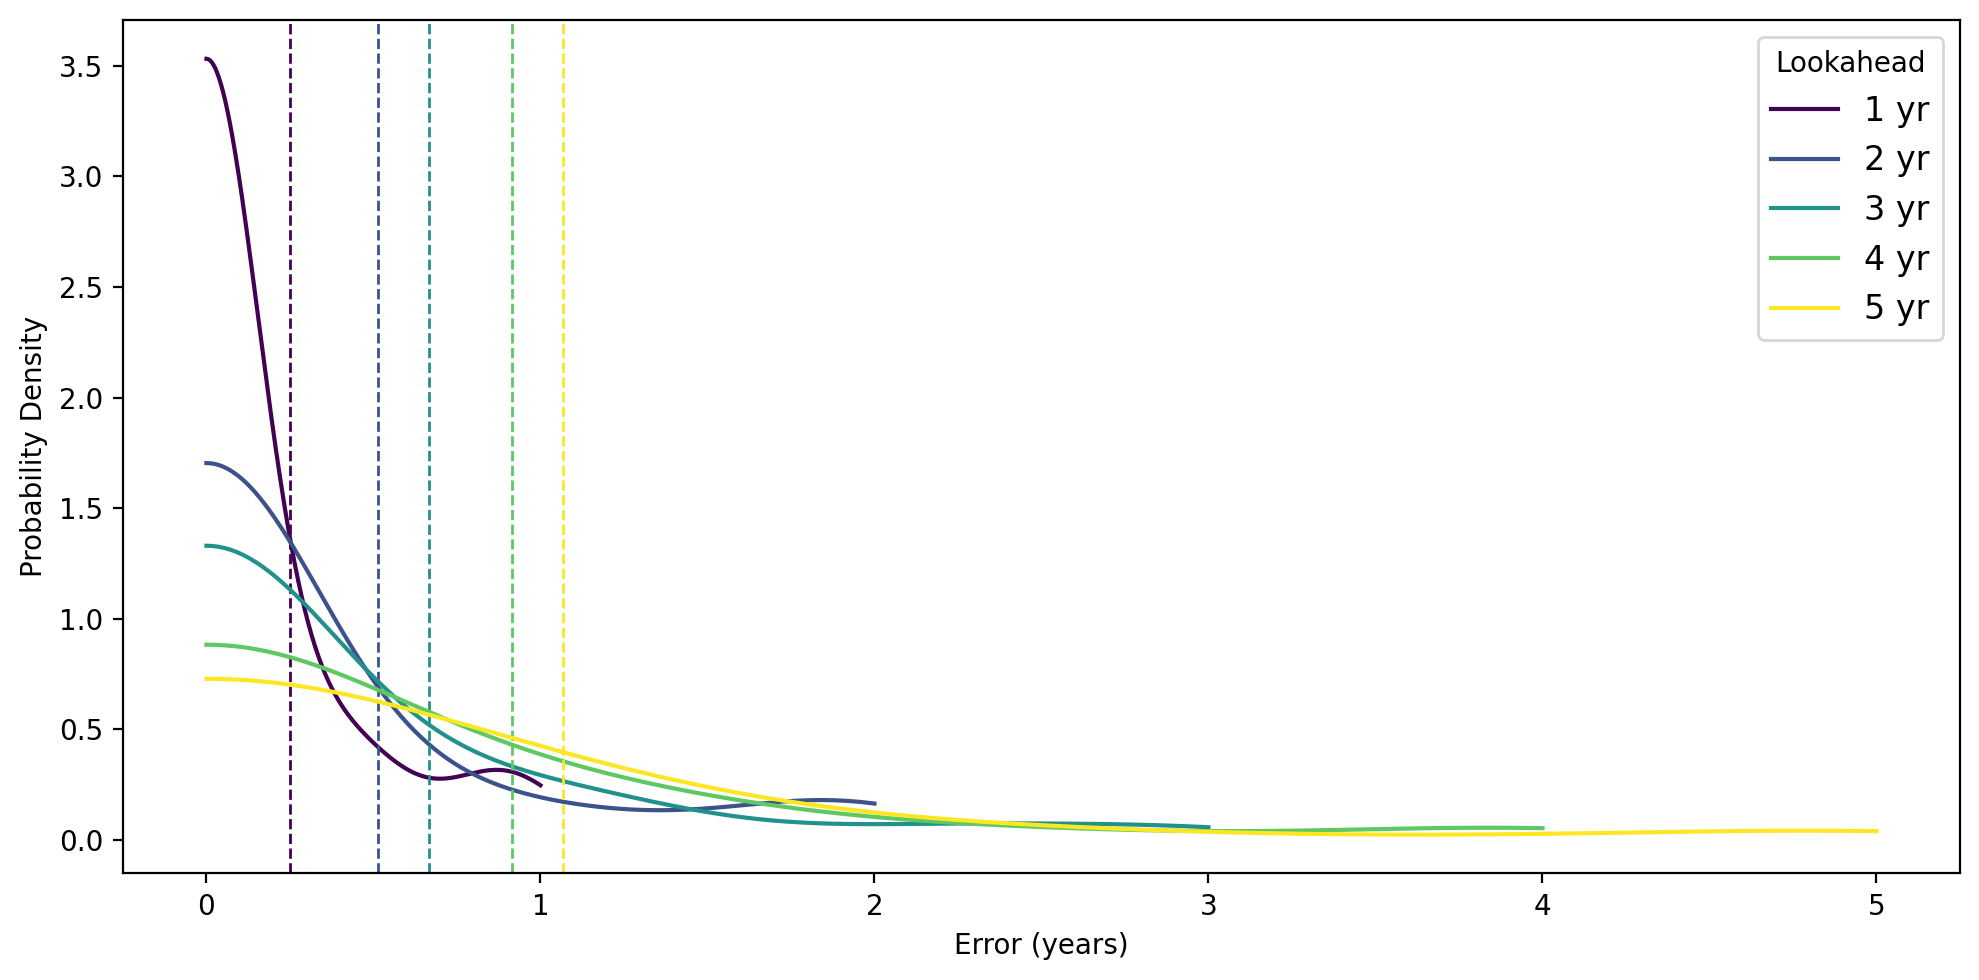

+----------------+----------------+
| Lookahead (yr) | Post Mean (yr) |
+----------------+----------------+
|       1        |     0.251      |
|       2        |     0.512      |
|       3        |     0.667      |
|       4        |     0.916      |
|       5        |     1.066      |
+----------------+----------------+


In [13]:
# df looks like a list of parameters for the lookahead windows tested for each

plot_return_errors(df)

- Now let's try seeing how this spread works on some simulated data.